# Part 9 — RLHF with GRPO: A Walkthrough

## The same performer — now graded on a curve against the room 🎭

This is the **last** part of the course, and it's a small, beautiful edit to Part 8. Before any code, here's the one picture to keep in your head the whole way through:

> Part 8 put the new hire on stage as a **performer** (the policy), let the **judge** (the Part-7 reward model) score each take, and hired a **coach** (PPO) to improve it. But that coach came with an expensive assistant: a **critic** — the value head — a *second network* whose only job was to *guess* "this take will score about a 7," so the coach could ask "did the take beat the guess?" GRPO looks at that assistant and asks: **why are we paying someone to guess the average, when we could just measure it?** So it **fires the critic.** Instead of one take and a guess, the performer does the **same audition piece several times** — a *group* of takes — the judge scores each, and every take is graded against the **group's own average**. Beat your group average → do more of that take; fall below it → do less. **The room is the baseline.**

That's the entire idea of **GRPO (Group Relative Policy Optimization)**. Everything else you already learned in Part 8 stays *exactly* the same — the two rails are untouched: *change gradually* (the **clip**) and *stay yourself* (the **KL leash** back to the frozen SFT model). Swap a few words and you have the real thing:

| In the rehearsal room | In RLHF-GRPO (the code) | Section |
|---|---|---|
| the **performer** doing takes | the **policy** (SFT-initialized `GPTModern`) | 9.1 |
| ~~the critic guessing each score~~ **(fired)** | ~~the value head~~ — **present but ignored** | 9.1 |
| **do the piece G times** | a **group** of completions per prompt (`group_size`) | 9.2 |
| the **judge** scoring each take | the **reward model** (reused from Part 7, frozen) | 9.3 |
| **"did this take beat my group average?"** ⭐ | the **group baseline** `A = r − mean(r over the group)` ⭐ | **9.4 ⭐** |
| **"don't overhaul your technique from one rep"** | the **clip** `min(unclipped, clipped)` *(same as Part 8)* | 9.5 |
| **"don't morph into someone else to game the judge"** | the **KL penalty** `+ kl_coef·KL(new‖ref)` *(now in the loss)* | 9.5 |
| the **coach** running one feedback cycle | the **GRPO step** in `train_grpo.py` | 9.6 |
| **did the rehearsal actually help?** | `eval_ppo.py` (avg reward vs reference) | 9.7 |

**The one sentence that separates GRPO from PPO:** *PPO learned a critic network to estimate the baseline; GRPO samples a group and uses the group's average reward as the baseline instead.* Same "better than expected?" question — answered by the **peer group** rather than a **gut estimate**.

**Why anyone bothers:** the critic in PPO is a whole second network — extra parameters, extra memory, its own MSE loss, and (in our toy build) it sat on the *logits* rather than hidden states, so it was a crude guess anyway. GRPO throws all of that away. The price it pays is **compute**: you must generate `G` completions per prompt instead of one. You trade *more rollouts* for *no critic* — and on modern hardware where generation is cheap and memory is precious, that's often a great deal. This is the algorithm behind DeepSeek's R1.

**What you should know going in (all from Part 8):**
- `PolicyWithValue` — the same actor(+critic) wrapper; here the critic is dead weight.
- the **rollout** (`generate` + `model_logprobs` → `old_logp`) — identical to Part 8.
- the **reward model** from Part 7 — frozen, just *used*.
- the **clipped surrogate** and the **KL** idea — Part 8's two rails, reused.
- "advantage = actual − baseline" — only the *baseline* changes here.

**What you'll build, step by step:**
1. **9.1** the performer (and the critic we no longer use) — `PolicyWithValue`
2. **9.2** a *group* of takes — `generate` G completions per prompt
3. **9.3** the judge scores each take — `RewardModel`
4. **9.4** the group baseline — `A = r − mean(group)` *(the heart of Part 9)* ⭐
5. **9.5** the policy-only loss — `grpo_loss.py` (clip kept, value loss gone, KL now a penalty)
6. **9.6** one full GRPO step — `train_grpo.py`, stripped to its spine
7. **9.7** did it improve? — `eval_ppo.py`

**One running example everywhere** — one prompt, carried through every cell:

> **Prompt:** `Explain the purpose of attention in transformers.`  *(literally the 1st fallback prompt in `rollout.sample_prompts()`)*

**Important — everything here uses FRESH models, no checkpoints.** Just like Part 8, we never load SFT/RM weights, so generated text is *gibberish*. That's fine and intended: the **wiring** (group rollout → score each → group baseline → clipped loss + KL → step) is 100% real production code; only the *weights* are random. We say so wherever a cell generates text, so you never mistake gibberish for a bug.


## The Map

Here's the whole GRPO cycle as a flowchart. You'll see this same diagram at the top of every section, with the step we're on lit up in green and the rest greyed out — so you always know where you are.

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style group fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style base fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style klpen fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

Reading it as one rehearsal cycle:
1. **prompt** — hand the performer a question.
2. **a group of takes** (9.2) — the policy generates **G** answers *for the same prompt* and records `old_logp` for every token of every take.
3. **judge** (9.3) — the frozen Part-7 reward model scores *each* finished take → `r_1 … r_G`.
4. **group baseline ⭐** (9.4) — subtract the group's *average* reward from each take's reward: `A_i = r_i − mean`. Takes above the group average get a positive advantage; below, negative. **No critic involved.**
5. **clipped surrogate** (9.5) — push up the probability of moves from above-average takes, *clipped* so one rep can't overhaul the technique. *(Identical to Part 8.)*
6. **KL penalty** (9.5) — add `kl_coef·KL(new‖ref)` directly to the loss so the policy stays close to the frozen SFT reference. *(In Part 8 this lived in the reward; in GRPO it's a loss term.)*
7. **GRPO step** (9.6) — one backward pass + AdamW update on the policy only.
8. **did it improve?** (9.7) — score the updated policy vs the frozen reference.

**The two contrasts with Part 8 — spot them on the map:**
- Where Part 8 had a **critic node** feeding the advantage, GRPO has **no critic** — the `base` node is computed straight from the *group* of takes.
- Where Part 8's **KL leash** sat *before* the advantage (it shaped the reward), GRPO's **KL penalty** sits *after* the clip (it's a term in the loss).

**Where this sits in the whole course:** Part 6 taught the hire to imitate, Part 7 built the judge, Part 8 closed the loop with PPO. **Part 9 is the same loop, simpler** — and it's the finish line.

**The single most important idea in this part:** you don't need a learned critic to know "better than expected." Generate a group, and *the group's average is the expectation.*


## Setup

Run this cell once. This notebook lives inside `part_9/`. We add the sibling parts **and the project root** to the import path so the **real** production modules import cleanly — including the namespace import `from part_6.formatters import …` that `rollout.py` does on its own — then fix a seed. We also force the **byte tokenizer** so every token id is a plain, readable byte.


In [1]:
import sys
from pathlib import Path
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd()                       # expects to be run from inside part_9/
ROOT = HERE.parent                      # ".../15. Build LLM From Scratch"

# ROOT first: lets `from part_6.formatters import ...` (inside rollout.py) resolve
# as a namespace package. Then the sibling parts so bare-name imports work.
for p in [str(ROOT), str(ROOT/"part_3"), str(ROOT/"part_4"), str(ROOT/"part_6"),
          str(ROOT/"part_7"), str(ROOT/"part_9"), str(HERE)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Force the byte tokenizer (vocab=256) for visibility: every id is a single byte.
import rollout
rollout._HAS_BPE = False                # flip BPE off so the trace uses readable byte ids

torch.manual_seed(0)
np.set_printoptions(precision=3, suppress=True)

# Tiny dims used by every runnable cell (fresh models, CPU, seconds to run).
V, BLK, NL, NH, NE = 256, 128, 2, 2, 64   # vocab, block_size, n_layer, n_head, n_embd
print("ready - torch", torch.__version__, "| working dir:", HERE.name)
print("NOTE: PAD token id is hard-coded as 2 (model_reward.py & train_grpo.py). With the byte")
print("      tokenizer that is the byte 0x02 - a silent magic number worth remembering.")


ready - torch 2.10.0+cpu | working dir: part_9
NOTE: PAD token id is hard-coded as 2 (model_reward.py & train_grpo.py). With the byte
      tokenizer that is the byte 0x02 - a silent magic number worth remembering.


### Our running example

We carry one prompt through the whole notebook, so every reward, group average, advantage, and clipped-loss value traces back to one thread.


In [2]:
from rollout import sample_prompts

PROMPT = "Explain the purpose of attention in transformers."   # 1st fallback prompt
assert PROMPT in sample_prompts(16)              # prove it is the baked-in anchor
print("anchor prompt:", PROMPT)


anchor prompt: Explain the purpose of attention in transformers.


---
## 9.1 The Performer (and the Critic We Fire)

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style group fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style base fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style klpen fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

> **Part 8 memory:** `PolicyWithValue` was an **actor-critic**: the LM picked tokens (actor) and a value head guessed each position's score (critic), used as the PPO baseline.
>
> **Part 9 now:** it's the *exact same class* — but GRPO **never uses the value head.** `train_grpo.py` builds `PolicyWithValue`, then calls `policy(seq, None)` and throws away the `values` output (`logits_new, _, _ = policy(...)`). The critic is along for the ride as dead weight; the baseline now comes from the group (9.4).

### What we're doing here, and why

The performer is unchanged from Part 8 — the Part-3 `GPTModern` LM, SFT-initialized, doing takes. We still *load* `PolicyWithValue` (so checkpoints and code stay compatible with Part 8), but the value head is now a vestigial organ: present in the object, ignored by the training loop.

### The bookkeeping (optional)

The class is identical to Part 8's (`policy.py`), and so is its forward pass:

```python
logits, loss, _ = self.lm(x, y)              # GPTModern: (B,T,V) logits
values = self.val_head(logits).squeeze(-1)   # (B,T) — computed, but GRPO ignores it
return logits, values, loss
```

**Gotcha worth knowing — the critic is fired, not deleted.** A from-scratch GRPO implementation would just use the bare `GPTModern` and skip the value head entirely. This codebase keeps `PolicyWithValue` so Part 8 and Part 9 can share `policy.py`; the loop simply never reads `values`. When you see `logits_new, _, _ = policy(seq, None)` in `train_grpo.py`, that discarded middle slot **is** the fired critic.


In [3]:
from policy import PolicyWithValue

torch.manual_seed(0)
pol = PolicyWithValue(vocab_size=V, block_size=BLK, n_layer=NL, n_head=NH, n_embd=NE)

x = torch.randint(0, V, (1, 16))             # one fake take, T=16
logits, values, loss = pol(x, None)
print("logits:", tuple(logits.shape))        # (1, 16, 256)
print("values:", tuple(values.shape))        # (1, 16)  <- the critic still computes this...
print("loss  :", loss)                        # None (y=None)
print("...but GRPO calls `logits, _, _ = policy(seq, None)` and discards `values`.")


logits: (1, 16, 256)
values: (1, 16)
loss  : None
...but GRPO calls `logits, _, _ = policy(seq, None)` and discards `values`.


### Shape trace

| Stage | Shape | GRPO uses it? |
|---|---|---|
| input ids `x` | `(1, 16)` | — |
| `lm(x) → logits` | `(1, 16, 256)` | **yes** (the actor) |
| `val_head(logits) → values` | `(1, 16)` | **no** (critic fired) |

### Why it matters (simple → practical → deeper)

- **Simple:** the actor stays; the critic goes.
- **Practical:** dropping the critic halves the "extra" machinery RLHF needs — no second network to size, train, or tune.
- **Deeper:** PPO is *actor-critic*; GRPO is *actor-only with a sampled baseline*. Recognizing the value head as optional is the conceptual jump of this whole part.


---
## 9.2 A GROUP of Takes (the Rollout)

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style group fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style base fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style klpen fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 8 memory:** the rollout generated **one** take per prompt and recorded `old_logp` for its tokens.
>
> **Part 9 now:** the rollout machinery (`generate`, `model_logprobs`) is **byte-for-byte identical** — but `train_grpo.py` wraps it in a loop that generates **G completions for the same prompt** (`group_size`, default 4). Those `G` takes are the *group*, and they're the only reason 9.4 can compute a baseline.

### What we're doing here, and why

To grade a take "on a curve," you need a curve — several takes of the *same* piece. So for each prompt the policy does it `G` times. Because we want the takes to actually *differ* (a flat group has no curve), `train_grpo.py` samples with `temperature=2, top_k=3` — deliberately high temperature to spread the group out.

### The bookkeeping (optional)

The grouping loop, distilled from `train_grpo.py`:

```python
for pid, p_ids in enumerate(prompt_in_ids):     # for each prompt...
    for g in range(G):                          # ...do G takes
        out = policy.generate(idx, max_new_tokens=resp_len, temperature=2, top_k=3)
        resp_ids = out[0].tolist()[boundary:]   # split off the response
        r = compute_reward(rm, tok, prompt, resp_ids)   # 9.3: score this take
        prompt_id_of.append(pid)                # remember which prompt -> which group
```

Each take records `prompt_id_of` so we know its group. After collection there are `B = P·G` trajectories total (`P` prompts × `G` takes each).

**The one detail people trip on:** the per-token log-prob recording (`model_logprobs`, the `(B, T-1)` shift) is *exactly* Part 8's. GRPO changes *how many sequences you collect and how you baseline them*, not how you score a single token. If 8.2 made sense, 9.2 is just "do it G times."


In [4]:
from rollout import RLHFTokenizer, format_prompt_only, model_logprobs

tok = RLHFTokenizer(block_size=BLK)          # byte tokenizer (we forced _HAS_BPE=False)
G = 4                                          # group_size: 4 takes per prompt

prefix = format_prompt_only(PROMPT).replace("</s>", "")
p_ids = tok.encode(prefix)[-BLK:]
idx = torch.tensor([p_ids], dtype=torch.long)

torch.manual_seed(0)
pol.eval()
group = []
for g in range(G):                             # G takes of the SAME prompt
    with torch.no_grad():
        out = pol.generate(idx, max_new_tokens=12, temperature=2.0, top_k=3)
    resp_ids = out[0].tolist()[len(p_ids):]
    group.append(out[0])
    print(f"take {g}: generated ids {resp_ids}  ->  {tok.decode(resp_ids)!r}")

print("\\ngroup size:", len(group), "(these G takes share one prompt -> they are one group)")
old_logp = model_logprobs(pol, group[0].unsqueeze(0))   # same per-token recording as Part 8
print("per-take old_logp shape:", tuple(old_logp.shape), "| all <= 0:", bool((old_logp <= 0).all()))


take 0: generated ids [117, 247, 159, 15, 247, 40, 239, 204, 29, 133, 105, 142]  ->  'u\x0f(\x1di'
take 1: generated ids [118, 82, 132, 53, 9, 92, 182, 23, 213, 228, 82, 132]  ->  'vR5\t\\\x17R'
take 2: generated ids [117, 247, 170, 209, 121, 177, 110, 61, 191, 35, 24, 129]  ->  'uyn=#\x18'
take 3: generated ids [117, 247, 40, 239, 152, 59, 156, 129, 10, 116, 230, 38]  ->  'u(;\nt&'
\ngroup size: 4 (these G takes share one prompt -> they are one group)
per-take old_logp shape: (1, 97) | all <= 0: True


**Gotcha worth knowing — temperature is high *on purpose*.** PPO could sample conservatively; GRPO *needs spread*. If all `G` takes were identical, they'd all equal the group mean and every advantage would be zero — nothing to learn. `temperature=2, top_k=3` keeps the group diverse so some takes beat the average and some don't.

### Why it matters

- **Simple:** one prompt, several attempts — that's the group.
- **Practical:** `G` is the key new knob. Bigger `G` = a more stable baseline (less noisy average) but `G×` the generation cost.
- **Deeper:** the group *is* the Monte-Carlo estimate of the prompt's expected reward. PPO learned that expectation with a network; GRPO samples it.


---
## 9.3 The Judge Scores Each Take (Reward)

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style group fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style base fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style klpen fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 7 memory:** you *trained* this `RewardModel` (encoder → masked-mean → scalar).
>
> **Part 8 memory:** it scored *one* take into one number `r`.
>
> **Part 9 now:** **same frozen judge, called G times** — once per take in the group → `r_1 … r_G`. These `G` scalars are the raw material the group baseline (9.4) turns into advantages. Nothing about the judge changes.

### What we're doing here, and why

The Part-7 judge walks in and scores *each* of the `G` takes, reading the whole formatted (prompt + response). One number per take. `compute_reward` in `train_grpo.py` is the same recipe as Part 8: decode the response, re-format with the Part-6 template, tokenize, run the reward model, take the scalar.


### The bookkeeping (optional)

`compute_reward`, copied from `train_grpo.py`:

```python
@torch.no_grad()
def compute_reward(reward_model, tok, prompt_text, response_ids, device):
    resp_text = tok.decode(response_ids)
    text = format_example(Example(prompt_text, resp_text))   # Part-6 chat template
    ids  = tok.encode(text)
    x    = torch.tensor([ids[:tok.block_size]])              # clip to context
    return float(reward_model(x)[0].item())                  # one scalar per take
```

**The one detail people trip on:** the reward is **one scalar per *whole take*** (a trajectory-level reward), not per token. In PPO we placed that scalar on the last token and shaped it token-by-token with KL; in GRPO the scalar stays at the trajectory level — we baseline it against the group *first* (9.4), then broadcast the resulting advantage to every action token of that take.


In [5]:
from model_reward import RewardModel
from part_6.formatters import Example, format_example   # resolves via ROOT on sys.path

torch.manual_seed(0)
rm = RewardModel(vocab_size=V, block_size=BLK, n_layer=NL, n_head=NH, n_embd=NE).eval()

def compute_reward(prompt_text, full_ids, boundary):
    resp_text = tok.decode(full_ids[boundary:])
    text = format_example(Example(prompt_text, resp_text))
    ids = tok.encode(text)[:BLK]
    z = torch.tensor([ids], dtype=torch.long)
    with torch.no_grad():
        return float(rm(z)[0].item())

raw_rewards = [compute_reward(PROMPT, t.tolist(), len(p_ids)) for t in group]
print("G =", G, "raw rewards (one per take):")
for g, r in enumerate(raw_rewards):
    print(f"  take {g}: r = {r:+.4f}")
print("\\n(a FRESH judge -> these are basically random, but the MECHANISM is real)")


G = 4 raw rewards (one per take):
  take 0: r = -0.0171
  take 1: r = +0.0005
  take 2: r = +0.0045
  take 3: r = +0.0058
\n(a FRESH judge -> these are basically random, but the MECHANISM is real)


C:\Users\MSI\AppData\Roaming\Python\Python314\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


### Why it matters

- **Simple:** every take gets one score.
- **Practical:** these `G` scores are all GRPO needs — no value targets, no critic regression.
- **Deeper:** because the reward is trajectory-level, GRPO doesn't even need per-token credit assignment; the group baseline handles "which take was better" and the whole take shares the credit.


---
## 9.4 Graded on a Curve: the Group Baseline ⭐

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style group fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style base fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style klpen fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 8 memory:** advantage = `shaped_r − old_values`, where `old_values` came from the **critic** (the value head's guess).
>
> **Part 9 now — the one change that defines GRPO:** advantage = `r − mean(r over the group)`. The baseline is the **group's own average reward**. Same subtraction as Part 8 — but the "expected" number is *measured from a group of takes*, not *guessed by a network*. **This single line is the entire difference between PPO and GRPO.**

### What we're doing here, and why

A teacher grading on a curve doesn't need to predict each student's score in advance — they just compute the class average and see who beat it. GRPO grades each take the same way: subtract the group's average reward. A take that scored above its group's average gets a **positive** advantage (do more of that); below average gets **negative** (do less); exactly average gets **zero** (neutral). Because we subtract the *mean*, the advantages in each group **sum to zero** — there's always something to push up and something to push down.


### The bookkeeping (optional)

The group baseline, distilled from `train_grpo.py`:

```python
# group the takes by their prompt, average each group's rewards:
for pid in range(P):
    idxs = [i for i in range(B) if prompt_id_of[i] == pid]
    group_mean[idxs] = raw_rewards[idxs].mean()        # the curve for this prompt

traj_adv = raw_rewards - group_mean                    # A_i = r_i - mean(group)
adv_flat = traj_adv[traj_id_for_token]                 # broadcast to each take's action tokens
adv_flat = (adv_flat - adv_flat.mean()) / adv_flat.std().clamp_min(1e-6)   # normalize
```

As an equation, for take $i$ belonging to the group $\mathcal{G}$ of completions sharing its prompt:

$$A_i \;=\; r_i \;-\; \frac{1}{|\mathcal{G}|}\sum_{j \in \mathcal{G}} r_j$$

That's it. Compare it to Part 8's `A = r − value_head(state)` — same shape, but the baseline went from a *learned scalar* to a *group average*.

**Gotcha worth knowing — trajectory-level advantage, broadcast to tokens.** Each take gets **one** advantage number, and *every action token in that take shares it* (`adv_flat = traj_adv[traj_id_for_token]`). There's no per-token value, no GAE — the whole response is reinforced or discouraged together. **Second gotcha:** this code subtracts the group mean and *then* normalizes the whole batch by its global std (mean 0, std 1). Canonical GRPO often divides each group by *its own* std; this build subtracts the group mean then z-normalizes globally. Same spirit (a baseline + a scale), slightly different bookkeeping.


In [6]:
# --- The idea in clean synthetic numbers first (one group of G=4 takes) ---
syn_rewards = torch.tensor([2.0, 1.0, 0.5, 0.5])     # made-up scores for 4 takes of one prompt
syn_mean = syn_rewards.mean()                        # the "curve" = group average
syn_adv = syn_rewards - syn_mean                     # advantage = beat-the-average
print("rewards   :", syn_rewards.tolist())
print("group mean:", float(syn_mean))                # 1.0
print("advantage :", syn_adv.tolist(), " <- best take +1.0, two below -0.5, average one 0.0")
print("sum of advantages:", float(syn_adv.sum()), " <- ALWAYS ~0 (we subtracted the mean)")
print("\\nNo critic predicted '1.0' - we MEASURED it from the group. That is GRPO.")


rewards   : [2.0, 1.0, 0.5, 0.5]
group mean: 1.0
advantage : [1.0, 0.0, -0.5, -0.5]  <- best take +1.0, two below -0.5, average one 0.0
sum of advantages: 0.0  <- ALWAYS ~0 (we subtracted the mean)
\nNo critic predicted '1.0' - we MEASURED it from the group. That is GRPO.


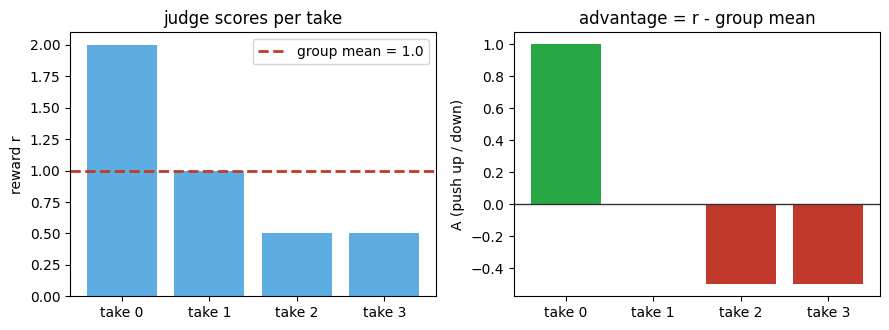

Green = above the curve (reinforce). Red = below (discourage). The group is its own yardstick.


In [7]:
# --- Picture it: rewards vs the group-average curve, and the resulting advantages ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9, 3.4))
takes = [f"take {i}" for i in range(4)]

axL.bar(takes, syn_rewards.numpy(), color="#5dade2")
axL.axhline(float(syn_mean), color="#c0392b", ls="--", lw=2, label=f"group mean = {float(syn_mean):.1f}")
axL.set_title("judge scores per take"); axL.set_ylabel("reward r"); axL.legend()

colors = ["#28a745" if a > 0 else ("#c0392b" if a < 0 else "#999") for a in syn_adv]
axR.bar(takes, syn_adv.numpy(), color=colors)
axR.axhline(0, color="#333", lw=1)
axR.set_title("advantage = r - group mean"); axR.set_ylabel("A (push up / down)")
plt.tight_layout(); plt.show()
print("Green = above the curve (reinforce). Red = below (discourage). The group is its own yardstick.")


In [8]:
# --- The REAL group from 9.2/9.3 (fresh model -> tiny spread, but the mechanism is identical) ---
raw_t = torch.tensor(raw_rewards)
grp_mean = raw_t.mean()                               # single prompt -> the whole group is one curve
adv = raw_t - grp_mean
print("real rewards   :", [round(x, 4) for x in raw_rewards])
print("real group mean:", round(float(grp_mean), 4))
print("real advantages:", [round(float(a), 4) for a in adv])
print("sum ~ 0        :", round(float(adv.sum()), 6))
print("\\nFresh weights -> the takes score almost the same, so advantages are tiny.")
print("With trained SFT+RM the spread is real and the best take pulls clearly ahead.")


real rewards   : [-0.0171, 0.0005, 0.0045, 0.0058]
real group mean: -0.0016
real advantages: [-0.0155, 0.0021, 0.0061, 0.0074]
sum ~ 0        : 0.0
\nFresh weights -> the takes score almost the same, so advantages are tiny.
With trained SFT+RM the spread is real and the best take pulls clearly ahead.


### Shape trace

| Tensor | Shape | Meaning |
|---|---|---|
| `raw_rewards` | `(G,)` per prompt, `(B,)` overall | one scalar per take |
| `group_mean` | `(B,)` | each take's group average (the curve) |
| `traj_adv` | `(B,)` | `r − group mean`, one per take |
| `adv_flat` | `(N_act,)` | broadcast to every action token, then normalized |

### Why it matters

- **Simple:** beat your group's average → do more of it.
- **Practical:** a group average is an *unbiased* baseline (subtracting it doesn't bias the gradient, it just cuts variance) — and it costs zero extra parameters.
- **Deeper:** this is the whole trade. PPO spent a network to *learn* the baseline; GRPO spends `G×` generations to *sample* it. Everything downstream (the clip, the KL, the step) is unchanged — which is why GRPO is "PPO minus the critic."


---
## 9.5 The Policy-Only Loss (clip kept, critic gone, KL moved)

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style group fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style base fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style klpen fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

> **Part 8 memory:** `ppo_losses` returned **three** terms — the clipped policy loss, a **value MSE** (to train the critic), and an entropy bonus — and the KL lived upstream in the *reward*.
>
> **Part 9 now:** `grpo_loss.py`'s `ppo_policy_only_losses` keeps the **clipped surrogate exactly as-is**, **drops the value loss** (no critic to train), and adds the **KL as a direct penalty term in the loss**: `total = policy_loss + kl_coef·KL(new‖ref)`. Three changes, one of them (the clip) is "no change at all."

### What we're doing here, and why

The clipped surrogate is *identical* to Part 8 — `ratio = exp(new_logp − old_logp)`, then `min(unclipped, clipped)`, the trust-region rail that flattens past `1 ± ε`. If you understood 8.5, you already understand the policy term here. What's new is what's *missing* (the value loss) and what *moved* (the KL).


### The bookkeeping (optional)

The whole function (`grpo_loss.py`) — notice how much *shorter* it is than `ppo_loss.py`:

```python
ratio       = torch.exp(new_logp - old_logp)
unclipped   = ratio * adv
clipped     = torch.clamp(ratio, 1 - clip_ratio, 1 + clip_ratio) * adv
policy_loss = -torch.mean(torch.min(unclipped, clipped))   # SAME clip as PPO

entropy   = -new_logp.mean() if ent_coef != 0.0 else 0.0   # off by default
approx_kl = torch.mean(old_logp - new_logp)                # logging only
kl_ref    = kl_mean                                        # KL(new||ref), passed in

total = policy_loss - ent_coef*entropy + kl_coef*kl_ref    # <-- KL is a LOSS term now
```

$$L^{\text{GRPO}} = \underbrace{-\,\mathbb{E}\big[\min(r A,\;\text{clip}(r,1{-}\epsilon,1{+}\epsilon)A)\big]}_{\text{same clipped surrogate as PPO}} \;+\; \underbrace{\beta\,\mathrm{KL}(\pi_\theta\,\|\,\pi_{\text{ref}})}_{\text{KL now in the loss}}$$

**The three diffs from `ppo_loss.py`, in one place:**

| | PPO (Part 8, `ppo_loss.py`) | GRPO (Part 9, `grpo_loss.py`) |
|---|---|---|
| clipped surrogate | yes | **yes (unchanged)** |
| value loss `MSE(new_values, returns)` | yes (`+ vf_coef·value_loss`) | **gone** (no critic) |
| KL term | upstream, shapes the **reward** (`r − kl·…`) | **in the loss** (`+ kl_coef·KL(new‖ref)`) |
| entropy bonus | present, off by default | present, off (*"not in original GRPO paper"*) |

**Gotcha worth knowing — two different KLs, don't mix them up.** `approx_kl = mean(old_logp − new_logp)` is a *diagnostic* (how far did this update move the policy from the snapshot?) and never enters the loss. `kl_ref = KL(new‖ref)` is the *penalty* (how far is the policy from the frozen SFT reference?) and is the only KL in `total`.


In [9]:
from grpo_loss import ppo_policy_only_losses

# Mirror tests/test_grpo_loss.py exactly: ratio=1.2, adv=+1, clip=0.1, KL=0.5, kl_coef=0.1
N = 32
old_logp_s = torch.zeros(N)                      # log pi_old = 0 -> pi_old = 1.0
new_logp_s = torch.log(torch.full((N,), 1.2))    # ratio = 1.2 (just past the clip)
adv_s      = torch.ones(N)                        # positive advantage
kl_mean_s  = torch.tensor(0.5)                    # pretend KL(policy || ref) = 0.5

out = ppo_policy_only_losses(new_logp_s, old_logp_s, adv_s,
                             clip_ratio=0.1, ent_coef=0.0, kl_coef=0.1, kl_mean=kl_mean_s)
print(f"policy_loss : {out.policy_loss.item():+.4f}   (ratio 1.2 clipped to 1.1 -> -1.1)")
print(f"kl_ref      : {out.kl_ref.item():+.4f}   (the KL penalty term, = kl_mean)")
print(f"approx_kl   : {out.approx_kl.item():+.4f}   (diagnostic only: mean(old-new) = -log 1.2)")
print(f"total_loss  : {out.total_loss.item():+.4f}   (= policy_loss + 0.1 * kl_ref = -1.1 + 0.05)")
print("total is scalar:", out.total_loss.ndim == 0, "  <- exactly what test_grpo_loss.py asserts")


policy_loss : -1.1000   (ratio 1.2 clipped to 1.1 -> -1.1)
kl_ref      : +0.5000   (the KL penalty term, = kl_mean)
approx_kl   : -0.1823   (diagnostic only: mean(old-new) = -log 1.2)
total_loss  : -1.0500   (= policy_loss + 0.1 * kl_ref = -1.1 + 0.05)
total is scalar: True   <- exactly what test_grpo_loss.py asserts


### Picture it — the clipped surrogate (the part that *didn't* change)

The policy term is the same shape you met in Part 8: a good move (advantage +1, green) climbs with the ratio then **flattens at 1.2**; a bad move (advantage −1, red) is the mirror image, flat below 0.8. The flat shelves are the trust region. GRPO inherits this verbatim — only the baseline that *produces* the advantage changed.


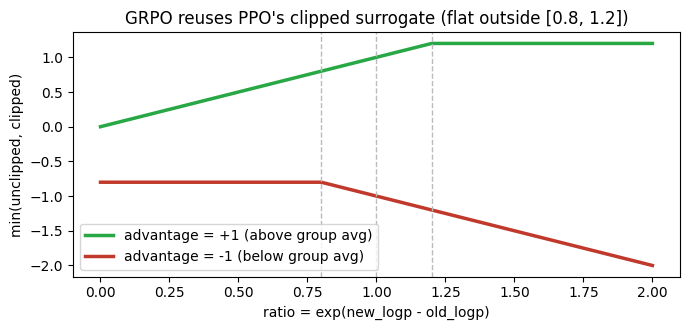

Same trust region as Part 8 - the clip is the piece GRPO does NOT touch.


In [10]:
ratios = np.linspace(0.0, 2.0, 400)
eps = 0.2
fig, ax = plt.subplots(figsize=(7, 3.4))
for A, color, label in [(+1.0, "#28a745", "advantage = +1 (above group avg)"),
                        (-1.0, "#c0392b", "advantage = -1 (below group avg)")]:
    surrogate = np.minimum(ratios * A, np.clip(ratios, 1 - eps, 1 + eps) * A)
    ax.plot(ratios, surrogate, color=color, lw=2.5, label=label)
for xref in (1 - eps, 1.0, 1 + eps):
    ax.axvline(xref, color="#bbb", ls="--", lw=1)
ax.set_title("GRPO reuses PPO's clipped surrogate (flat outside [0.8, 1.2])")
ax.set_xlabel("ratio = exp(new_logp - old_logp)")
ax.set_ylabel("min(unclipped, clipped)")
ax.legend(); plt.tight_layout(); plt.show()
print("Same trust region as Part 8 - the clip is the piece GRPO does NOT touch.")


### Why it matters

- **Simple:** less code, same safety rails.
- **Practical:** dropping the value MSE means there's no critic loss to balance (no `vf_coef` to tune) — one fewer moving part.
- **Deeper:** moving the KL from the reward into the loss is mostly a bookkeeping choice, but it makes the regularizer explicit and easy to anneal — you can read `kl_coef` straight off the `total` line.


---
## 9.6 One Full GRPO Step (the Loop)

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style group fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style judge fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style base fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style clip fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style klpen fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style step fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 8 memory:** `train_ppo.py` was rollout → score → KL-shaped reward → advantage(− critic) → clipped loss(+ value) → step.
>
> **Part 9 now:** `train_grpo.py` is the same skeleton with two edits — generate a **group** per prompt, and replace "advantage minus critic" with "**advantage minus group mean**." Everything else (mask, logprobs, clip, AdamW, policy-only update) is the same.

### What we're doing here, and why

One full GRPO cycle, wired from the **real** `train_grpo.py` pieces — group generation, the action mask, the group baseline, `ppo_policy_only_losses`, `backward`, `opt.step` — on tiny fresh models so it runs on CPU in seconds. We use `P = 2` prompts × `G = 4` takes = `B = 8` trajectories.

**Gotcha worth knowing — at step 0 the loss is near zero, and that's correct.** The reference is a fresh *copy* of the policy, so `new_logp ≈ old_logp ≈ ref_logp`: the ratio is ≈1 (so the clipped surrogate ≈ `−mean(advantage)` ≈ 0, since advantages sum to ~0) and `KL(new‖ref)` ≈ 0. The loss only grows once the policy starts to move. **Second gotcha:** `train_grpo.py` computes `kl_tok = old_logp − ref_logp` and writes a comment about "trajectory-level KL shaping" — but that line is **never used**; the advantage is pure `reward − group mean`, and the KL enters *only* through the loss penalty. A vestigial line worth not being confused by.


In [11]:
from grpo_loss import ppo_policy_only_losses
from rollout import sample_prompts

# Reuse pol / rm / tok from above. Build a frozen reference (deepcopy of the policy).
ref = copy.deepcopy(pol)
for p_ in ref.parameters():
    p_.requires_grad_(False)
ref.eval()

opt = torch.optim.AdamW(pol.parameters(), lr=1e-5)
kl_coef = 0.01
P, G = 2, 4                                     # 2 prompts, 4 takes each -> B = 8 trajectories
prompts = sample_prompts(P)

# ----- COLLECT A GROUP PER PROMPT (generate G takes, score each) -----
pol.eval()
seq_list, bnd_list, pid_of, raw_rewards = [], [], [], []
torch.manual_seed(0)
for pid, pr in enumerate(prompts):
    pfx = format_prompt_only(pr).replace("</s>", "")
    pr_ids = tok.encode(pfx)[-BLK:]
    ix = torch.tensor([pr_ids], dtype=torch.long)
    for g in range(G):                          # the group
        with torch.no_grad():
            full = pol.generate(ix, max_new_tokens=16, temperature=2.0, top_k=3)[0].tolist()
        bnd = len(pr_ids)
        resp = tok.decode(full[bnd:])
        zt = torch.tensor([tok.encode(format_example(Example(pr, resp)))[:BLK]], dtype=torch.long)
        with torch.no_grad():
            r = rm(zt)[0].item()
        seq_list.append(torch.tensor(full, dtype=torch.long))
        bnd_list.append(bnd); pid_of.append(pid); raw_rewards.append(r)

# ----- PAD into a batch + build the action mask -----
B = len(seq_list)
max_len = min(BLK, max(s.numel() for s in seq_list))
seq  = torch.full((B, max_len), 2, dtype=torch.long)      # PAD id = 2
mask = torch.zeros(B, max_len, dtype=torch.bool)
for i, (s, b) in enumerate(zip(seq_list, bnd_list)):
    L = min(s.numel(), max_len)
    seq[i, :L] = s[:L]
    mask[i, b:L] = True                                    # response tokens = the actions
act_mask = mask[:, 1:]                                     # shift to align with logprobs

# ----- SNAPSHOT logprobs (old + ref), detached -----
with torch.no_grad():
    old_logp = model_logprobs(pol, seq)[act_mask].detach()
    ref_logp = model_logprobs(ref, seq)[act_mask].detach()

# ----- GROUP BASELINE: advantage = reward - group mean (the 9.4 heart) -----
raw_rewards_t = torch.tensor(raw_rewards)
group_mean = torch.zeros(B)
for pid in range(P):
    members = torch.tensor([i for i in range(B) if pid_of[i] == pid])
    group_mean[members] = raw_rewards_t[members].mean()    # each prompt's curve
traj_adv = raw_rewards_t - group_mean                      # one advantage per take
tok_to_traj = torch.tensor([i for i in range(B) for _ in range(int(act_mask[i].sum()))])
adv_flat = traj_adv[tok_to_traj]                           # broadcast to action tokens
adv_flat = (adv_flat - adv_flat.mean()) / adv_flat.std().clamp_min(1e-6)

# ----- ONE GRPO UPDATE (recompute new_logp WITH grad; value head ignored) -----
pol.train()
logits_new, _, _ = pol(seq, None)                          # <- the discarded slot is the fired critic
new_logp_all = torch.log_softmax(logits_new[:, :-1, :], dim=-1).gather(
    -1, seq[:, 1:].unsqueeze(-1)).squeeze(-1)
new_logp = new_logp_all[act_mask]
kl_now_ref = (new_logp - ref_logp).mean()                  # KL(new || ref) for the penalty

out = ppo_policy_only_losses(new_logp, old_logp, adv_flat,
                             clip_ratio=0.2, ent_coef=0.0, kl_coef=kl_coef, kl_mean=kl_now_ref)

w_before = pol.lm.tok_emb.weight.detach().clone()
opt.zero_grad(set_to_none=True)
out.total_loss.backward()
torch.nn.utils.clip_grad_norm_(pol.parameters(), 1.0)
opt.step()
moved = (pol.lm.tok_emb.weight.detach() - w_before).abs().sum().item()

print(f"P={P} prompts x G={G} takes = B={B} trajectories | action tokens N = {new_logp.numel()}")
print(f"group means per prompt: {[round(float(group_mean[[i for i in range(B) if pid_of[i]==pid][0]]),4) for pid in range(P)]}")
print(f"total_loss {out.total_loss.item():+.4f} | policy {out.policy_loss.item():+.4f} "
      f"| kl_ref {out.kl_ref.item():.6f} | approx_kl {out.approx_kl.item():+.6f}")
print(f"policy weights moved (sum|delta| of tok_emb): {moved:.3e}   (ref + rm untouched)")
print("one real GRPO step completed (loss ~0 at step 0: ratio~1, KL~0 vs the fresh copy) OK")


P=2 prompts x G=4 takes = B=8 trajectories | action tokens N = 128
group means per prompt: [-0.029, -0.0103]
total_loss +0.0000 | policy -0.0000 | kl_ref 0.000000 | approx_kl +0.000000
policy weights moved (sum|delta| of tok_emb): 5.926e-02   (ref + rm untouched)
one real GRPO step completed (loss ~0 at step 0: ratio~1, KL~0 vs the fresh copy) OK


### Shape trace (B = P·G = 8)

| Tensor | Shape |
|---|---|
| `seq`, `mask` | `(8, max_len)` |
| `act_mask` | `(8, max_len-1)` bool |
| `raw_rewards_t`, `group_mean`, `traj_adv` | `(8,)` — one per take |
| `old_logp`, `ref_logp`, `new_logp`, `adv_flat` | `(N,)` — N = # action tokens |
| `out.total_loss` | scalar `()` |

### Why it matters

- **Simple:** this single cell *is* GRPO — every other section was a part of it.
- **Practical:** the diff from `train_ppo.py` is tiny — a group loop and one changed baseline line — which is exactly why GRPO is easy to adopt once you have PPO.
- **Deeper:** the loop is still *on-policy* (the data shifts as the policy learns), so the clip and the KL penalty remain mandatory — GRPO simplifies the *baseline*, not the *safety rails*.


---
## 9.7 Did It Improve? (Evaluation)

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style group fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style base fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style klpen fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 8 memory:** evaluation was *average reward* — tuned policy vs frozen SFT reference, on held-out prompts.
>
> **Part 9 now:** **identical metric, same file** — `eval_ppo.py` (yes, still named `*_ppo`; GRPO reuses it). Generate from both the GRPO-tuned policy and the frozen reference, average the judge's scores, compare. A positive gap = the rehearsal paid off.

### What we're doing here, and why

After rehearsals, check the tape: does the performer now score higher than before coaching? `eval_ppo.py` generates from both models on a fixed prompt pool and averages the judge's scores. A positive delta is the headline result of RLHF — and it's measured the same way whether the coach was PPO or GRPO.

**Gotcha worth knowing — the filename and a hardcoded path are both Part-8 leftovers.** Part 9's eval script is literally still called `eval_ppo.py`, and it loads the SFT reference from the literal string `"../part_6/runs/sft-demo/model_last.pt"`. We don't use real checkpoints here, so we build a fresh frozen reference and show the *mechanism* — generate-from-both, score-both, compare-means — not a meaningful number.


In [12]:
# Compare avg judge reward: GRPO-tuned policy (after the 9.6 step) vs the frozen reference.
def avg_reward(model, prompts):
    scores = []
    model.eval()
    for prompt in prompts:
        prefix = format_prompt_only(prompt).replace("</s>", "")
        pr_ids = tok.encode(prefix)[-BLK:]
        ix = torch.tensor([pr_ids], dtype=torch.long)
        with torch.no_grad():
            gen = model.generate(ix, max_new_tokens=16, temperature=0.2, top_k=5)[0].tolist()
        resp = tok.decode(gen[len(pr_ids):])
        zt = torch.tensor([tok.encode(format_example(Example(prompt, resp)))[:BLK]], dtype=torch.long)
        with torch.no_grad():
            scores.append(rm(zt)[0].item())
    return sum(scores) / len(scores)

eval_prompts = sample_prompts(4)
r_policy = avg_reward(pol, eval_prompts)
r_ref    = avg_reward(ref, eval_prompts)
print(f"avg judge reward | GRPO policy: {r_policy:+.4f} | frozen reference: {r_ref:+.4f}")
print(f"delta (policy - reference): {r_policy - r_ref:+.4f}")
print("\\nWith FRESH weights this delta is noise - the point is the mechanism (generate both, score")
print("both, compare means). With orchestrator.py --demo (real SFT+RM ckpts) it becomes the real gain.")


avg judge reward | GRPO policy: -0.0070 | frozen reference: -0.0078
delta (policy - reference): +0.0008
\nWith FRESH weights this delta is noise - the point is the mechanism (generate both, score
both, compare means). With orchestrator.py --demo (real SFT+RM ckpts) it becomes the real gain.


### Why it matters

- **Simple:** higher average judge score = success.
- **Practical:** this single number is how every RLHF run is reported — PPO or GRPO.
- **Deeper:** it's also where *reward hacking* shows up — a high RM score on gibberish means the KL penalty was too weak. Eval is your honesty check, exactly as in Part 8.


---
## Closing the loop — and the course

```mermaid
graph LR
    prompt["9.2 prompt<br>one instruction"]
    group["9.2 a GROUP of takes<br>G completions per prompt"]
    judge["9.3 judge scores each<br>reward r_1..r_G"]
    base["9.4 group baseline<br>A = r - mean(group)"]
    clip["9.5 clipped surrogate<br>min(unclipped, clipped)"]
    klpen["9.5 KL penalty in the loss<br>+ kl_coef * KL(new||ref)"]
    step["9.6 one GRPO step<br>backward + AdamW"]
    ev["9.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> group --> judge --> base --> clip --> klpen --> step --> ev
    step -. repeat .-> prompt
    ref -. KL penalty .-> klpen

    style prompt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style group fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style judge fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style base fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style clip fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style klpen fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style step fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ev fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ref fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

**The one-sentence takeaway:** GRPO is PPO with the critic fired — generate a *group* of takes, use the **group's average reward as the baseline**, and keep the same clipped surrogate and KL leash. ⭐

### The whole rehearsal, in one breath

- **9.1 Performer** — the same `PolicyWithValue`, but the value-head critic is ignored.
- **9.2 A group of takes** — generate `G` completions per prompt (high temperature for spread).
- **9.3 Judge scores each** — the frozen Part-7 reward model, called `G` times → `r_1…r_G`.
- **9.4 Group baseline ⭐** — `A = r − mean(group)`: beat your group average, do more *(the one idea to remember)*.
- **9.5 Policy-only loss** — same clip, value loss dropped, KL moved into the loss term.
- **9.6 One GRPO step** — group rollout → score → group baseline → clipped loss + KL → AdamW, policy only.
- **9.7 Did it improve?** — average judge reward, tuned policy vs frozen reference.

### PPO vs GRPO, side by side

| | PPO (Part 8) | GRPO (Part 9) |
|---|---|---|
| baseline for the advantage | **learned critic** (value head) | **group average reward** |
| takes per prompt | 1 | **G** (a group) |
| value/critic loss | yes (`vf_coef·MSE`) | **none** |
| KL regularizer | shapes the **reward** | term in the **loss** |
| clipped surrogate | yes | **yes (identical)** |
| extra network to train | the critic | **none** |
| extra cost | — | `G×` generations per prompt |

### You now have everything needed to read every file in `part_9/`

- [policy.py](policy.py) — 9.1 the performer (`GPTModern` LM + a value head GRPO ignores)
- [rollout.py](rollout.py) — 9.2/9.3 tokenizer, `generate`, `model_logprobs`, `sample_prompts` *(same as Part 8)*
- [grpo_loss.py](grpo_loss.py) — 9.5 **the policy-only clipped surrogate + KL penalty ⭐**
- [train_grpo.py](train_grpo.py) — 9.4/9.6 the GRPO loop (group rollout → group baseline → clipped step)
- [eval_ppo.py](eval_ppo.py) — 9.7 average RM reward, tuned policy vs frozen SFT reference
- [orchestrator.py](orchestrator.py) — runs the unit test, then the optional tiny demo
- [tests/test_grpo_loss.py](tests/test_grpo_loss.py) — proves the policy-only objective returns a scalar ⭐

**The one-line pipeline:** `prompt → policy generates a GROUP of takes (+ logprobs) → reward model scores each → advantage = r − group mean → clipped loss + KL(new‖ref) penalty → AdamW on the policy → repeat → eval avg reward.`

**Run the real thing** (from inside `part_9/`):

```bash
python orchestrator.py          # runs the unit test
python orchestrator.py --demo   # test, then a tiny GRPO run + eval (needs Part 6 SFT + Part 7 RM checkpoints)
```

The demo expects `../part_6/runs/sft-demo/model_last.pt` and `../part_7/runs/rm-demo/model_last.pt`. The notebook above needs **neither** — it builds fresh tiny models so every wire is real even though the answers are gibberish.

### You've reached the end 🏁

You started in **Part 1** with a single attention head and finished here, in **Part 9**, training a language model with reinforcement learning from human feedback. Trace the whole arc you built:

- **Parts 1–4** — the transformer, then a real tiny LLM, then the modern upgrades (RMSNorm, RoPE, SwiGLU, KV cache), then scaling (BPE, AMP, schedules, checkpoints). *Pretraining: the model learns to predict text.*
- **Part 5** — Mixture-of-Experts: more capacity, same compute.
- **Part 6 (SFT)** — the new hire learns to *follow instructions* by imitation.
- **Part 7 (Reward Model)** — a judge learns your taste from comparisons.
- **Part 8 (PPO)** — the judge gets in the driver's seat; the policy optimizes for approval, with a critic and two rails.
- **Part 9 (GRPO)** — fire the critic; let the *group* be the baseline. *The simplest RLHF that still works — and the one behind today's reasoning models.*

The student you coached in Part 2 became the policy you tuned here. **That's a full modern LLM stack, built from scratch, end to end.** 🎉
